In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
data = {
    'Month': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'Customers': [120, 135, 150, 170, 160, 180, 200, 210, 190, 220, 250, 300],
    'Discount_Percent': [5, 8, 10, 12, 10, 15, 18, 20, 12, 10, 8, 5],
    'Seasonal_Factor': [1.0, 1.1, 1.0, 1.0, 1.1, 1.2, 1.3, 1.3, 1.2, 1.1, 1.2, 1.5],
    'Sales': [2000, 2300, 2600, 3000, 2800, 3500, 3900, 4200, 3600, 4300, 5000, 6200]
}

# Create DataFrame
df = pd.DataFrame(data)

print("Sales Dataset Collected")
print(df)

Sales Dataset Collected
    Month  Customers  Discount_Percent  Seasonal_Factor  Sales
0       1        120                 5              1.0   2000
1       2        135                 8              1.1   2300
2       3        150                10              1.0   2600
3       4        170                12              1.0   3000
4       5        160                10              1.1   2800
5       6        180                15              1.2   3500
6       7        200                18              1.3   3900
7       8        210                20              1.3   4200
8       9        190                12              1.2   3600
9      10        220                10              1.1   4300
10     11        250                 8              1.2   5000
11     12        300                 5              1.5   6200


In [5]:

print("Preprocessing Sales Records")

# Select features (input variables) and target (output)
X = df[['Customers', 'Discount_Percent', 'Seasonal_Factor']]  # Features
y = df['Sales']  # Target variable to predict

print("\nFeatures selected: Customers, Discount_Percent, Seasonal_Factor")
print("Target variable: Sales")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

Preprocessing Sales Records

Features selected: Customers, Discount_Percent, Seasonal_Factor
Target variable: Sales

Training data size: 9
Testing data size: 3


In [7]:
print("Sales Trends and Patterns")
# Sales trend by month
print("\nSales by Month:")
for i in range(len(df['Month'])):
    print(f"Month {df['Month'][i]}: {df['Sales'][i]} rupees")

# Average sales by season (based on seasonal factor)
high_season = df[df['Seasonal_Factor'] >= 1.2]['Sales'].mean()
low_season = df[df['Seasonal_Factor'] < 1.2]['Sales'].mean()

print(f"\nAverage Sales in High Season (factor >= 1.2): {high_season:.2f}")
print(f"Average Sales in Low Season (factor < 1.2): {low_season:.2f}")

# Correlation
print("\nCorrelation with Sales:")
print(f"Customers: {df['Customers'].corr(df['Sales']):.2f}")
print(f"Discount: {df['Discount_Percent'].corr(df['Sales']):.2f}")
print(f"Seasonal Factor: {df['Seasonal_Factor'].corr(df['Sales']):.2f}")

Sales Trends and Patterns

Sales by Month:
Month 1: 2000 rupees
Month 2: 2300 rupees
Month 3: 2600 rupees
Month 4: 3000 rupees
Month 5: 2800 rupees
Month 6: 3500 rupees
Month 7: 3900 rupees
Month 8: 4200 rupees
Month 9: 3600 rupees
Month 10: 4300 rupees
Month 11: 5000 rupees
Month 12: 6200 rupees

Average Sales in High Season (factor >= 1.2): 4400.00
Average Sales in Low Season (factor < 1.2): 2833.33

Correlation with Sales:
Customers: 1.00
Discount: 0.02
Seasonal Factor: 0.84


In [8]:
print(" Building Prediction Model")
# Create and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel trained successfully!")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

# Make predictions on test data
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

 Building Prediction Model

Model trained successfully!
Coefficients: [ 21.95495937   8.15739391 752.75486979]
Intercept: -1562.827397299147

Model Performance:
Mean Squared Error: 14812.67
R² Score: 0.9910


Visualizing Results

✓ Visualization saved as 'sales_prediction_results.png'
FUTURE SALES PREDICTION

Predicted Future Sales:
Scenario 1: Customers=320, Discount=6%
  → Predicted Sales: ₹6339.73
Scenario 2: Customers=340, Discount=7%
  → Predicted Sales: ₹6862.27
Scenario 3: Customers=360, Discount=8%
  → Predicted Sales: ₹7384.8
PROJECT COMPLETE!
Files created: sales_prediction_results.png


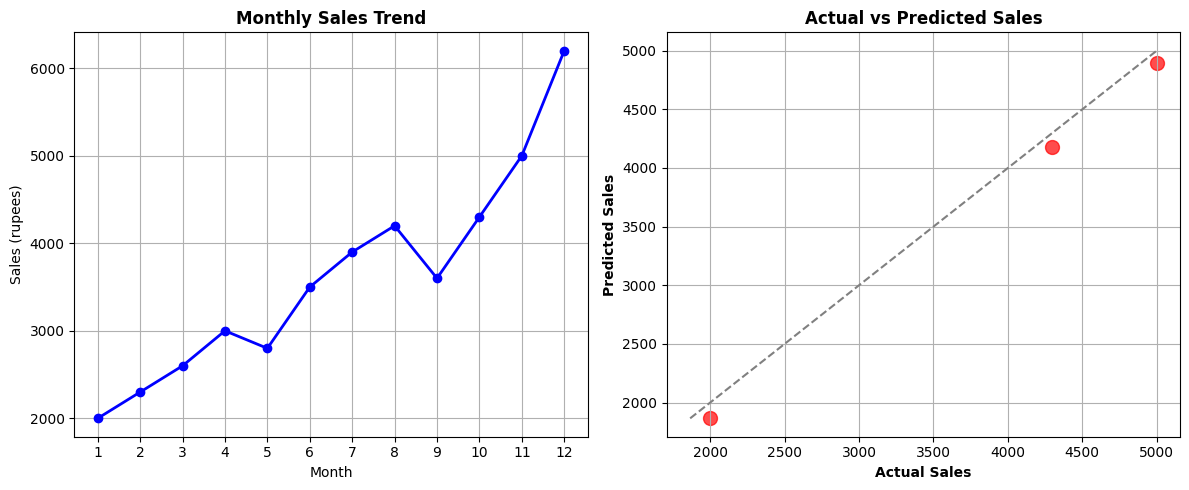

In [10]:
print("Visualizing Results")

# Create 2 graphs
plt.figure(figsize=(12, 5))

# Graph 1: Monthly Sales Trend
plt.subplot(1, 2, 1)
plt.plot(df['Month'], df['Sales'], marker='o', linewidth=2, color='blue')
plt.title('Monthly Sales Trend', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales (rupees)')
plt.grid(True)
plt.xticks(df['Month'])

# Graph 2: Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='red', alpha=0.7, s=100)
plt.xlabel('Actual Sales', fontweight='bold')
plt.ylabel('Predicted Sales', fontweight='bold')
plt.title('Actual vs Predicted Sales', fontweight='bold')
plt.grid(True)

# Add diagonal line (perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'gray', linestyle='--')

plt.tight_layout()
plt.savefig('sales_prediction_results.png', dpi=300)
print("\n✓ Visualization saved as 'sales_prediction_results.png'")

# Predict future sales
print("FUTURE SALES PREDICTION")

future_data = pd.DataFrame({
    'Customers': [320, 340, 360],
    'Discount_Percent': [6, 7, 8],
    'Seasonal_Factor': [1.1, 1.2, 1.3]
})

future_sales = model.predict(future_data)

print("\nPredicted Future Sales:")
for i in range(len(future_sales)):
    print(f"Scenario {i+1}: Customers={future_data['Customers'][i]}, Discount={future_data['Discount_Percent'][i]}%")
    print(f"  → Predicted Sales: ₹{round(future_sales[i], 2)}")

print("PROJECT COMPLETE!")
print("Files created: sales_prediction_results.png")

Visualization


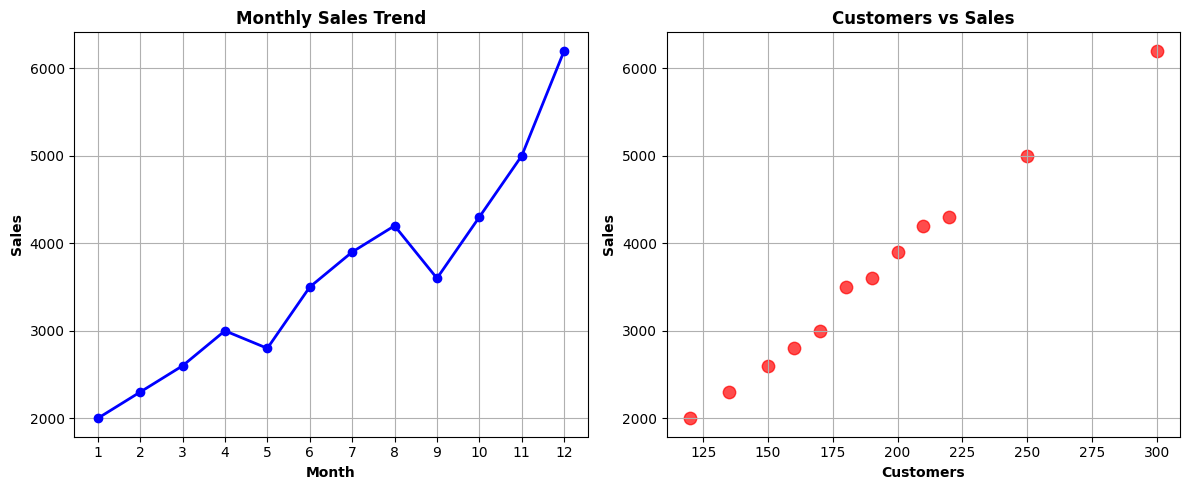

In [13]:
# Visualization
plt.figure(figsize=(12, 5))

# 1. Monthly Sales Trend (using the same Sales data)
plt.subplot(1, 2, 1)
plt.plot(data['Month'], data['Sales'], marker='o', color='blue', linewidth=2)
plt.title("Monthly Sales Trend", fontweight='bold')
plt.xlabel("Month", fontweight='bold')
plt.ylabel("Sales", fontweight='bold')
plt.grid(True)
plt.xticks(data['Month'])

# 2. Customers vs Sales (trend pattern)
plt.subplot(1, 2, 2)
plt.scatter(data['Customers'], data['Sales'], color='red', s=80, alpha=0.7)
plt.title("Customers vs Sales", fontweight='bold')
plt.xlabel("Customers", fontweight='bold')
plt.ylabel("Sales", fontweight='bold')
plt.grid(True)

plt.tight_layout()
plt.savefig("sales_visualization.png", dpi=300)
print("Visualization")